### یادگیری ماشین
مسئله 1 - بخش 1

In [2]:
%pip install utm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import utm

In [2]:
df_raw = pd.read_csv('../../data/Divar.csv', low_memory=False)

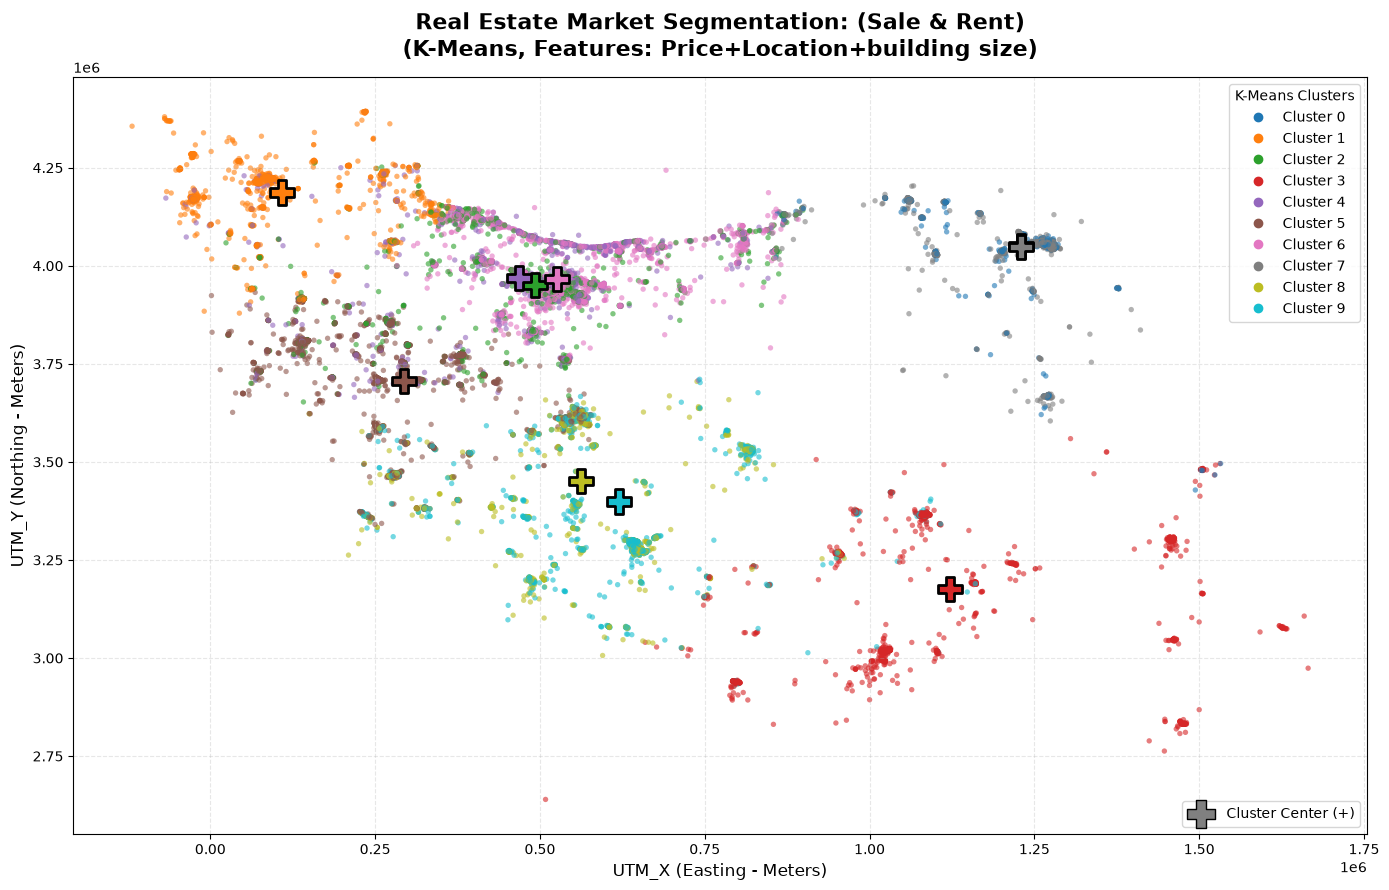

In [3]:
features = ['transformable_price', 'building_size', 'location_latitude', 'location_longitude']

# تبدیل ستون‌ها به عدد
for col in features:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

# حذف ردیف‌هایی که در این ۴ ستون مقدار خالی دارند
df_clean = df_raw.dropna(subset=features).copy()

#  حذف outliers 
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
df_ml = remove_outliers_iqr(df_clean, 'transformable_price')
df_ml = remove_outliers_iqr(df_ml, 'building_size')


# تبدیل مختصات به UTM
easting, northing, _, _ = utm.from_latlon(
    df_ml['location_latitude'].values, 
    df_ml['location_longitude'].values
)

df_ml['UTM_X'] = easting
df_ml['UTM_Y'] = northing

# استانداردسازی و اجرای K-Means
cluster_features = ['transformable_price', 'building_size', 'UTM_X', 'UTM_Y']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_ml[cluster_features])

# اجرای K-Means با 10 خوشه
kmeans = KMeans(n_clusters=10, init='k-means++', random_state=42, n_init=10)
df_ml['Cluster'] = kmeans.fit_predict(X_scaled)

# استخراج مراکز خوشه و بازگردانی به مقیاس واقعی
centroids_scaled = kmeans.cluster_centers_
centroids_real = scaler.inverse_transform(centroids_scaled)

# رسم نمودار
sample_df = df_ml.sample(n=min(50000, len(df_ml)), random_state=42)

fig, ax = plt.subplots(figsize=(14, 9))

scatter = ax.scatter(
    sample_df['UTM_X'], 
    sample_df['UTM_Y'], 
    c=sample_df['Cluster'], 
    cmap='tab10', 
    alpha=0.6, 
    s=15, 
    edgecolors='none',
    vmin=0, vmax=9
)

# رسم مراکز خوشه 
ax.scatter(
    centroids_real[:, 2],  
    centroids_real[:, 3],  
    c=range(10),           
    cmap='tab10',          
    vmin=0, vmax=9,       
    marker='P',           
    s=300,                 
    edgecolors='black',    
    linewidths=2,          
    zorder=10,             
)

handles, labels = scatter.legend_elements(prop="colors", alpha=1)
legend_clusters = ax.legend(
    handles, 
    [f"Cluster {i}" for i in range(10)], 
    loc="upper right", 
    title="K-Means Clusters",
    fontsize=10
)
ax.add_artist(legend_clusters)

ax.scatter([], [], c='gray', marker='P', s=400, edgecolors='black', label='Cluster Center (+)')
ax.legend(loc="lower right")

ax.set_title('Real Estate Market Segmentation: (Sale & Rent)\n(K-Means, Features: Price+Location+building size)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('UTM_X (Easting - Meters)', fontsize=12)
ax.set_ylabel('UTM_Y (Northing - Meters)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()


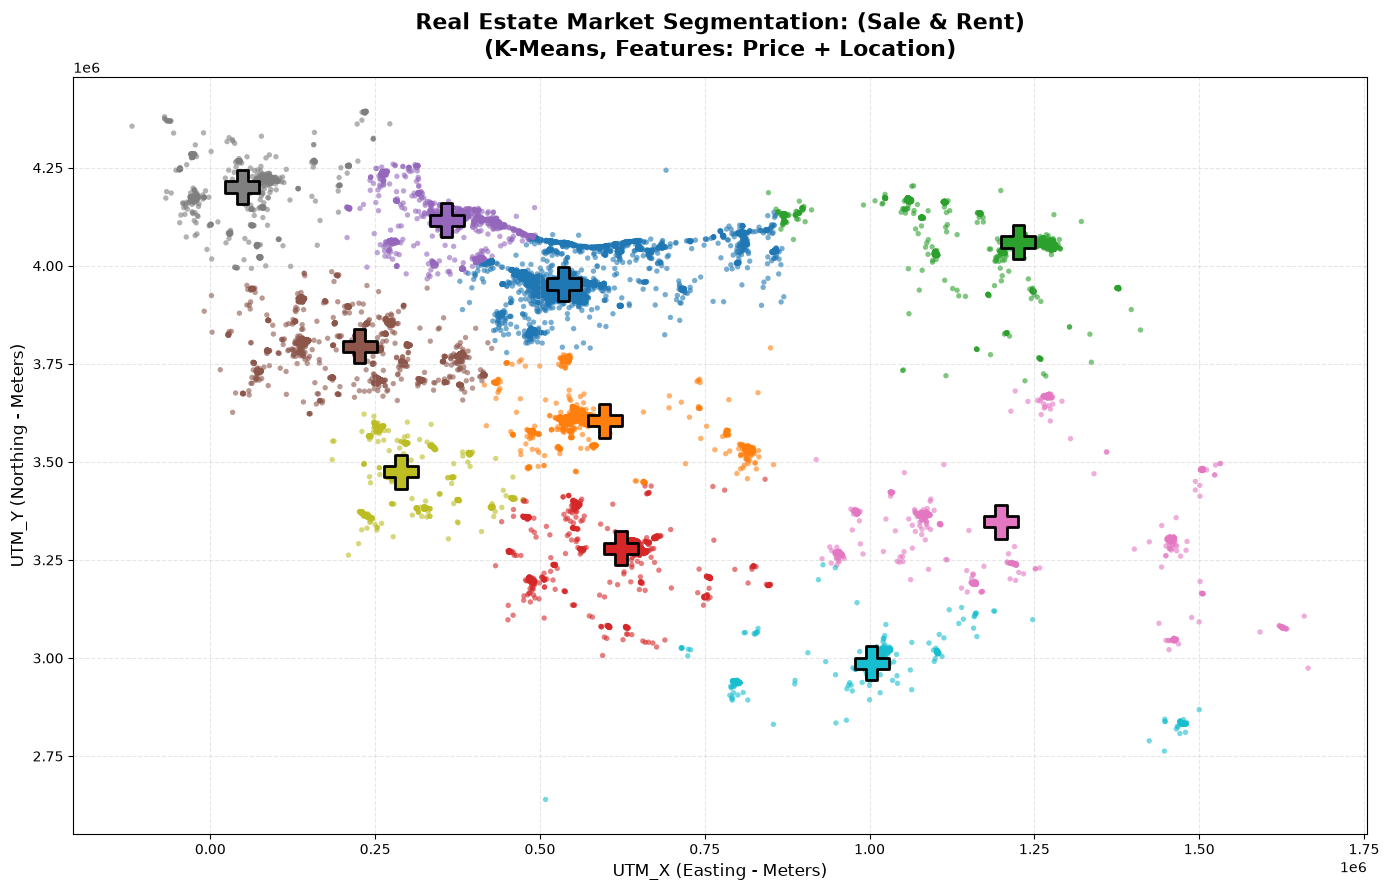

In [5]:
# خوشه بندی فقط با قیمت و لوکیشن 
cluster_features_no_size = ['transformable_price', 'UTM_X', 'UTM_Y']

scaler_no_size = StandardScaler()
X_scaled_no_size = scaler_no_size.fit_transform(df_ml[cluster_features_no_size])

kmeans_no_size = KMeans(n_clusters=10, init='k-means++', random_state=42, n_init=10)
df_ml['Cluster_No_Size'] = kmeans_no_size.fit_predict(X_scaled_no_size)

centroids_scaled_no_size = kmeans_no_size.cluster_centers_
centroids_real_no_size = scaler_no_size.inverse_transform(centroids_scaled_no_size)

sample_df = df_ml.sample(n=min(50000, len(df_ml)), random_state=42)

fig, ax = plt.subplots(figsize=(14, 9))

scatter = ax.scatter(
    sample_df['UTM_X'], 
    sample_df['UTM_Y'], 
    c=sample_df['Cluster_No_Size'], 
    cmap='tab10', 
    alpha=0.6, 
    s=15, 
    edgecolors='none',
    vmin=0, vmax=9
)

ax.scatter(
    centroids_real_no_size[:, 1],  # UTM_X
    centroids_real_no_size[:, 2],  # UTM_Y
    c=range(10),           
    cmap='tab10',          
    vmin=0, vmax=9,        
    marker='P',            
    s=600,                 
    edgecolors='black',    
    linewidths=2,          
    zorder=10,             
)

ax.set_title('Real Estate Market Segmentation: (Sale & Rent)\n(K-Means, Features: Price + Location)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('UTM_X (Easting - Meters)', fontsize=12)
ax.set_ylabel('UTM_Y (Northing - Meters)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

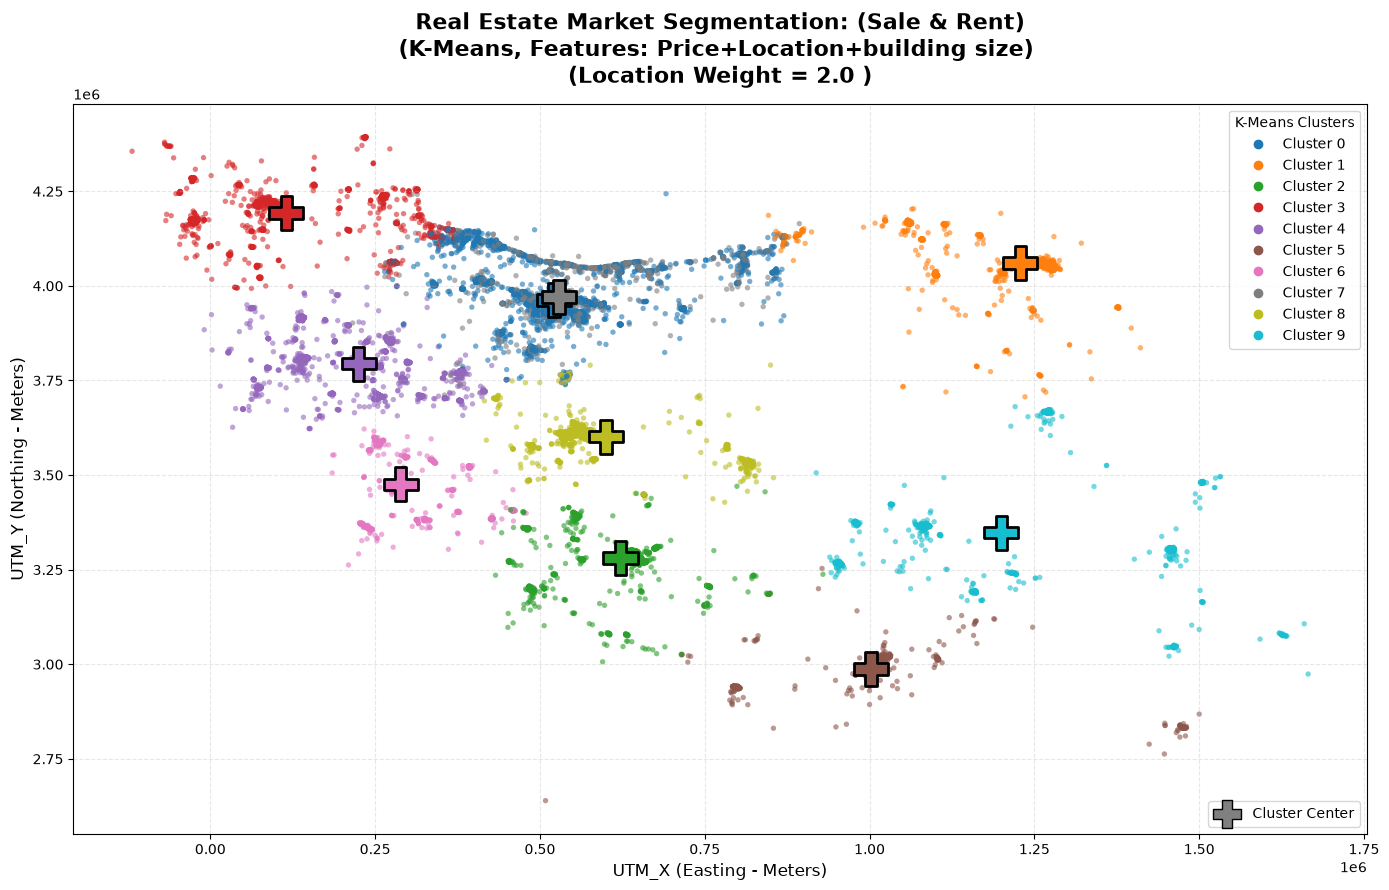

In [7]:

features = ['transformable_price', 'building_size', 'location_latitude', 'location_longitude']

for col in features:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

df_clean = df_raw.dropna(subset=features).copy()

def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

df_ml = remove_outliers_iqr(df_clean, 'transformable_price')
df_ml = remove_outliers_iqr(df_ml, 'building_size')

easting, northing, _, _ = utm.from_latlon(
    df_ml['location_latitude'].values, 
    df_ml['location_longitude'].values
)

df_ml['UTM_X'] = easting
df_ml['UTM_Y'] = northing

# استانداردسازی و اعمال وزن‌دهی(Feature Weighting)
cluster_features = ['transformable_price', 'building_size', 'UTM_X', 'UTM_Y']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_ml[cluster_features])
 
weights = np.array([1.0, 1.0, 2.0, 2.0])
X_weighted = X_scaled * weights

kmeans = KMeans(n_clusters=10, init='k-means++', random_state=42, n_init=10)
df_ml['Cluster'] = kmeans.fit_predict(X_weighted)

centroids_weighted = kmeans.cluster_centers_
centroids_unweighted = centroids_weighted / weights
centroids_real = scaler.inverse_transform(centroids_unweighted)


sample_df = df_ml.sample(n=min(50000, len(df_ml)), random_state=42)

fig, ax = plt.subplots(figsize=(14, 9))

scatter = ax.scatter(
    sample_df['UTM_X'], 
    sample_df['UTM_Y'], 
    c=sample_df['Cluster'], 
    cmap='tab10', 
    alpha=0.6, 
    s=15, 
    edgecolors='none',
    vmin=0, vmax=9
)

ax.scatter(
    centroids_real[:, 2],  # UTM_X
    centroids_real[:, 3],  # UTM_Y
    c=range(10),           
    cmap='tab10',          
    vmin=0, vmax=9,        
    marker='P',            
    s=600,                 
    edgecolors='black',    
    linewidths=2,          
    zorder=10,             
)

handles, labels = scatter.legend_elements(prop="colors", alpha=1)
legend_clusters = ax.legend(
    handles, 
    [f"Cluster {i}" for i in range(10)], 
    loc="upper right", 
    title="K-Means Clusters",
    fontsize=10
)
ax.add_artist(legend_clusters)

ax.scatter([], [], c='gray', marker='P', s=400, edgecolors='black', label='Cluster Center')
ax.legend(loc="lower right")

ax.set_title('Real Estate Market Segmentation: (Sale & Rent)\n(K-Means, Features: Price+Location+building size) \n(Location Weight = 2.0 )', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('UTM_X (Easting - Meters)', fontsize=12)
ax.set_ylabel('UTM_Y (Northing - Meters)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()


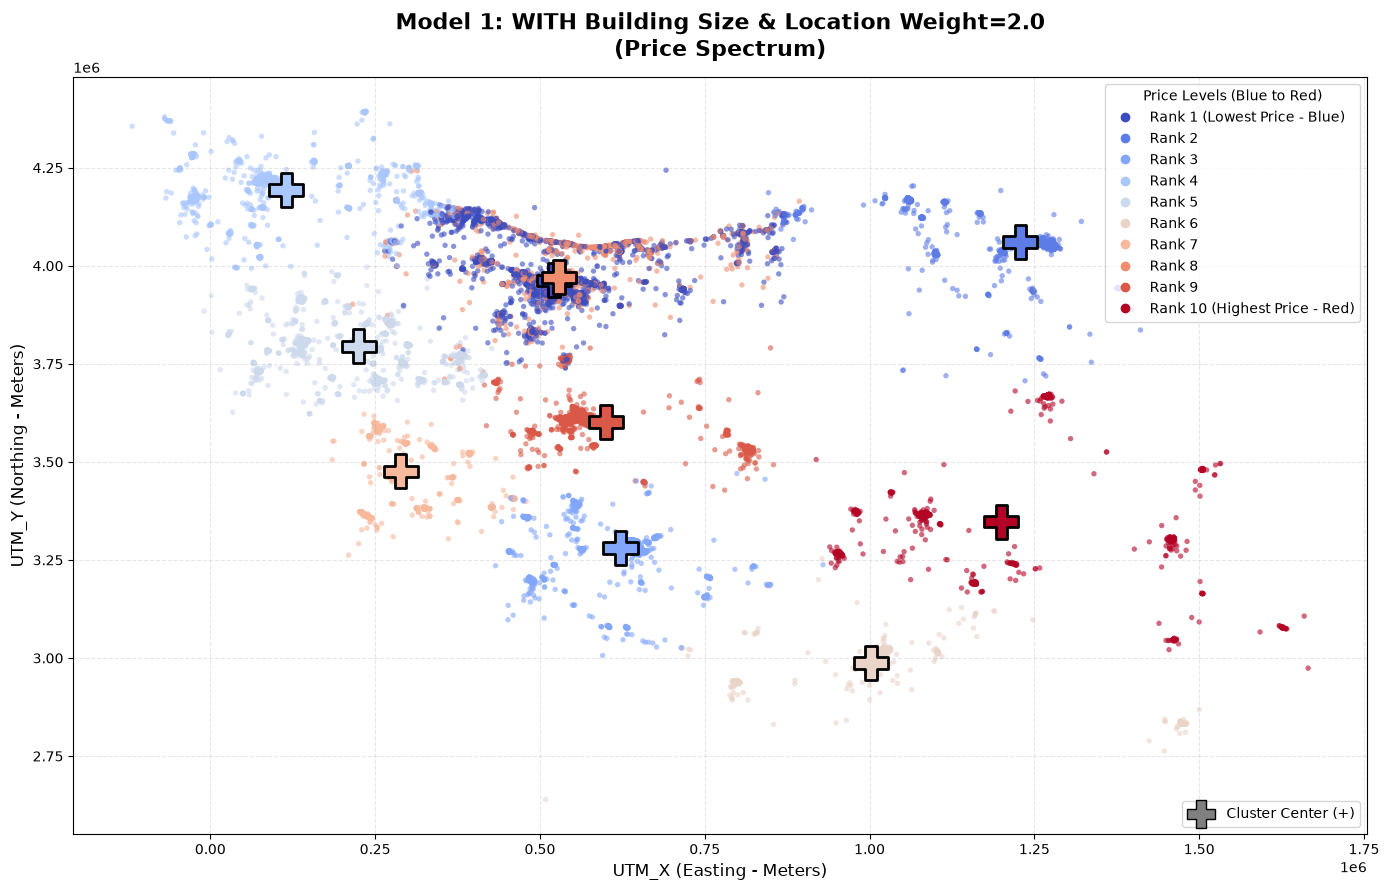

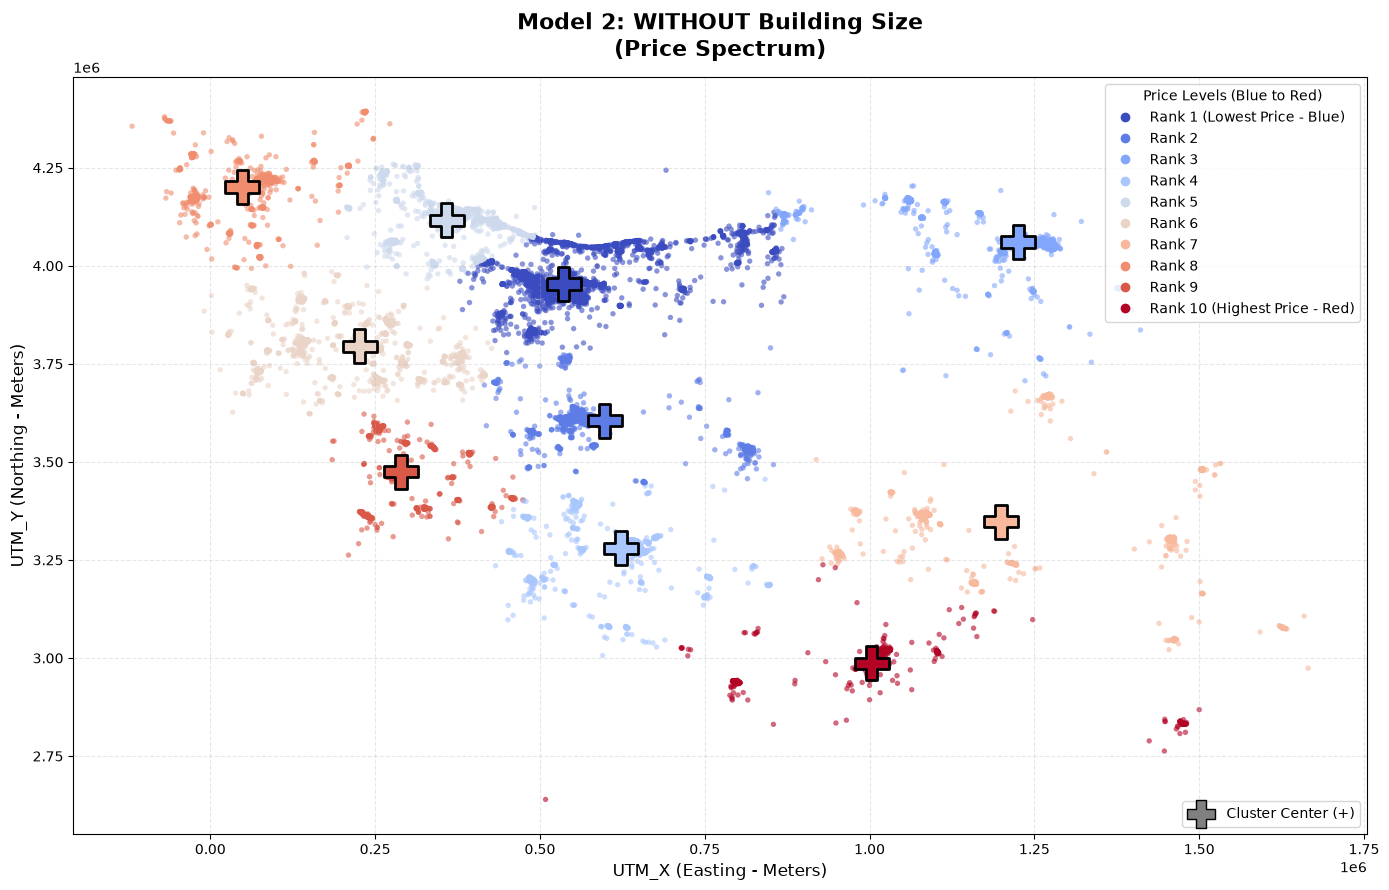

In [45]:
#  مقایسه دو مدل (با متراژ و بدون متراژ) با طیف حرارتی قیمت


sample_df = df_ml.sample(n=min(50000, len(df_ml)), random_state=42).copy()

#  ساخت مدل اول (با متراژ + وزن دو برابری لوکیشن)
features_1 = ['transformable_price', 'building_size', 'UTM_X', 'UTM_Y']
scaler_1 = StandardScaler()
X_scaled_1 = scaler_1.fit_transform(df_ml[features_1])

# اعمال وزن‌ها
weights = np.array([1.0, 1.0, 2.0, 2.0])
X_weighted_1 = X_scaled_1 * weights

kmeans_1 = KMeans(n_clusters=10, init='k-means++', random_state=42, n_init=10)
df_ml['Cluster_1'] = kmeans_1.fit_predict(X_weighted_1)

# بازگردانی مراکز به مقیاس واقعی
centroids_real_1 = scaler_1.inverse_transform(kmeans_1.cluster_centers_ / weights)

# رتبه‌بندی خوشه‌ها بر اساس قیمت (مدل ۱)
avg_price_1 = df_ml.groupby('Cluster_1')['transformable_price'].mean().sort_values()
rank_mapping_1 = {old_id: rank for rank, old_id in enumerate(avg_price_1.index)}
sample_df['Ordered_Cluster_1'] = df_ml.loc[sample_df.index, 'Cluster_1'].map(rank_mapping_1)
centroid_ranks_1 = [rank_mapping_1[i] for i in range(10)]

#  ساخت مدل دوم (بدون متراژ)
features_2 = ['transformable_price', 'UTM_X', 'UTM_Y']
scaler_2 = StandardScaler()
X_scaled_2 = scaler_2.fit_transform(df_ml[features_2])

kmeans_2 = KMeans(n_clusters=10, init='k-means++', random_state=42, n_init=10)
df_ml['Cluster_2'] = kmeans_2.fit_predict(X_scaled_2)

# بازگردانی مراکز به مقیاس واقعی
centroids_real_2 = scaler_2.inverse_transform(kmeans_2.cluster_centers_)

# رتبه‌بندی خوشه‌ها بر اساس قیمت (مدل ۲)
avg_price_2 = df_ml.groupby('Cluster_2')['transformable_price'].mean().sort_values()
rank_mapping_2 = {old_id: rank for rank, old_id in enumerate(avg_price_2.index)}
sample_df['Ordered_Cluster_2'] = df_ml.loc[sample_df.index, 'Cluster_2'].map(rank_mapping_2)
centroid_ranks_2 = [rank_mapping_2[i] for i in range(10)]

#  رسم نمودارها 
def plot_price_spectrum(df_plot, centroids, centroid_ranks, utm_x_idx, utm_y_idx, cluster_col, title):
    fig, ax = plt.subplots(figsize=(14, 9))
    
    # رسم نقاط خانه
    scatter = ax.scatter(
        df_plot['UTM_X'], df_plot['UTM_Y'], 
        c=df_plot[cluster_col], cmap='coolwarm', 
        alpha=0.6, s=15, edgecolors='none', vmin=0, vmax=9
    )
    
    # رسم مراکز خوشه 
    ax.scatter(
        centroids[:, utm_x_idx], centroids[:, utm_y_idx],
        c=centroid_ranks, cmap='coolwarm', vmin=0, vmax=9,
        marker='P', s=600, edgecolors='black', linewidths=2, zorder=10
    )
    
    handles, _ = scatter.legend_elements(prop="colors", alpha=1)
    ordered_labels = ["Rank 1 (Lowest Price - Blue)", "Rank 2", "Rank 3", "Rank 4", "Rank 5", 
                      "Rank 6", "Rank 7", "Rank 8", "Rank 9", "Rank 10 (Highest Price - Red)"]
    legend_clusters = ax.legend(handles, ordered_labels, loc="upper right", title="Price Levels (Blue to Red)", fontsize=10)
    ax.add_artist(legend_clusters)
    
    ax.scatter([], [], c='gray', marker='P', s=400, edgecolors='black', label='Cluster Center (+)')
    ax.legend(loc="lower right")
    
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('UTM_X (Easting - Meters)', fontsize=12)
    ax.set_ylabel('UTM_Y (Northing - Meters)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_price_spectrum(
    sample_df, centroids_real_1, centroid_ranks_1, 
    utm_x_idx=2, utm_y_idx=3, cluster_col='Ordered_Cluster_1', 
    title='Model 1: WITH Building Size & Location Weight=2.0\n(Price Spectrum)'
)

plot_price_spectrum(
    sample_df, centroids_real_2, centroid_ranks_2, 
    utm_x_idx=1, utm_y_idx=2, cluster_col='Ordered_Cluster_2', 
    title='Model 2: WITHOUT Building Size\n(Price Spectrum)'
)